# Day 1

In [37]:
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pylab as plt
from sklearn.model_selection import GridSearchCV
import pandas as pd


#### Using **Pipeline**

In [38]:
X,y = load_digits(return_X_y=True)
pipe = Pipeline([
    ('scale',StandardScaler()),
    ('model',KNeighborsClassifier())
])
pipe.fit(X,y)
pred=pipe.predict(X)


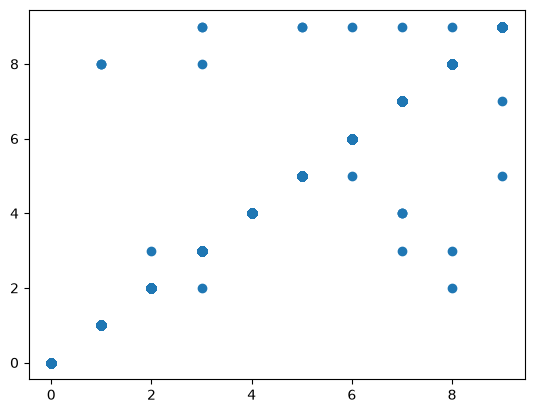

In [39]:
plt.scatter(pred,y)

#### What is the best n_neighbors to set ?
So using **GridSeachCv** will detrmine what is the best value for the **neighbors number**,

and it help us to split the dataset to 3 parts and with rounds not only one to get best performance 

so now with the 10 valuse for the n_neighbors and the 3 cv it will train the model 30 time to get the best result

In [40]:
mod = GridSearchCV(
    estimator=pipe,
    param_grid={'model__n_neighbors':[1,2,3,4,5,6,7,8,9,10],},
    cv=3
)
mod.fit(X,y)
pd.DataFrame(mod.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002203,0.000300,0.011658,0.001281,1,{'model__n_neighbors': 1},0.928214,0.944908,0.926544,0.933222,0.008291,8
1,0.001683,0.000045,0.010313,0.000363,2,{'model__n_neighbors': 2},0.938230,0.928214,0.928214,0.931553,0.004722,10
2,0.001930,0.000218,0.010860,0.000754,3,{'model__n_neighbors': 3},0.943239,0.941569,0.948247,0.944352,0.002838,1
3,0.001649,0.000135,0.010825,0.000454,4,{'model__n_neighbors': 4},0.939900,0.941569,0.943239,0.941569,0.001363,4
4,0.001926,0.000216,0.010475,0.000207,5,{'model__n_neighbors': 5},0.941569,0.941569,0.943239,0.942126,0.000787,3
5,0.001790,0.000095,0.011526,0.000668,6,{'model__n_neighbors': 6},0.944908,0.941569,0.933222,0.939900,0.004915,5
6,0.002285,0.000395,0.011218,0.000585,7,{'model__n_neighbors': 7},0.953255,0.938230,0.941569,0.944352,0.006442,1
7,0.001826,0.000153,0.012623,0.001143,8,{'model__n_neighbors': 8},0.939900,0.931553,0.934891,0.935448,0.003430,7
8,0.001723,0.000036,0.011767,0.000720,9,{'model__n_neighbors': 9},0.941569,0.929883,0.938230,0.936561,0.004915,6
9,0.001985,0.000350,0.012060,0.000441,10,{'model__n_neighbors': 10},0.936561,0.926544,0.933222,0.932109,0.004164,9


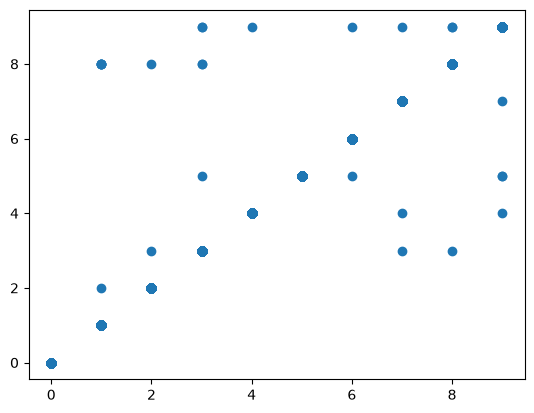

In [41]:
pred=mod.predict(X)
plt.scatter(pred,y)

## Hands-On Lab

### Step 1: Load a provided dataset and separate it into features X and target y. 

In [42]:
df = pd.read_csv("../../week1/day4/train.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [43]:
target ='Survived'
X= df.drop(target,axis=1)
y=df[target]
print(X.info())
print(y.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    str    
 3   Sex          891 non-null    str    
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    str    
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    str    
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB
None
<class 'pandas.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Survived
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB
None


### Step 2: Perform an 80/20 train/test split with a fixed random_state.

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

### Step 3: Confirm the shapes of X_train, X_test, y_train, y_test are consistent and print them.

In [46]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(712, 11)
(712,)
(179, 11)
(179,)


### Step 4: In a Markdown cell, explain in your own words why the model must never see the test set during training.

Its a big mistake if we **let the model train in the test set**, and thats because when he sees the test set, he will **save the prediciton** cuz in the training set it has the **featuers** and the **traget**, then after that when we try to predict it will give us a **high accurecy**, **is this correct** ?

**No**, the model saved the data not understand it, so we must test his accurecy in a data he never sees.

Test set job is to proivde **new, unsee data** this mistake ruin it.